# Image Denoising and Edge Detection with OpenCV
*A Python Tutorial for Image Processing and Microscopy*

## Introduction
In this notebook, we continue with OpenCV, a powerful library primarily designed for machine vision, but also extremely useful for scientific and microscopy image processing.

This notebook's focus is on two **essential preprocessing techniques**:

1. Denoising / Blurring
1. Edge Detection

These operations are often performed **before image segmentation**, **object detection**, or **quantitative analysis**, especially when working with noisy microscope images.

---

## Import libraries 

In [2]:
import cv2                 # OpenCV for image processing
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Plotting and visualization

Why these libraries?
- **OpenCV** (`cv2`) → Image processing operations
- **NumPy** (`np`) → Kernel creation and array manipulation
- **Matplotlib** (`plt`) → Histograms and plotting when needed

---

### Reading a Noisy Image
Let’s start by loading a grayscale image that contains noise.

In [23]:
img = cv2.imread("8.noisyCT.jpg", 0)  # 0 --> Read as grayscale

> `0` → grayscale   
> `1` → color image (BGR)

---

## Understanding Image Denoising

Denoising works by **reducing high-frequency noise** while preserving important image features.

**How does it work?**
- The image is treated as a **2D array**
- A **kernel (filter)** is slid across the image
- At each position, a mathematical operation (convolution) is applied

Common kernel sizes:
- 3×3 → Mild smoothing
- 5×5 → Stronger smoothing

---

## Custom Averaging Filter (Manual Kernel)
Let’s define our own **normalized averaging kernel** using NumPy.

In [24]:
kernel = np.ones((3, 3), np.float32) / 9
print(kernel)

[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


Why normalize?
- Ensures that pixel intensities don’t artificially increase or decrease
- The kernel values must sum to 1

### Applying the Filter

In [25]:
filtered_2d = cv2.filter2D(img, -1, kernel)

### Displaying Results

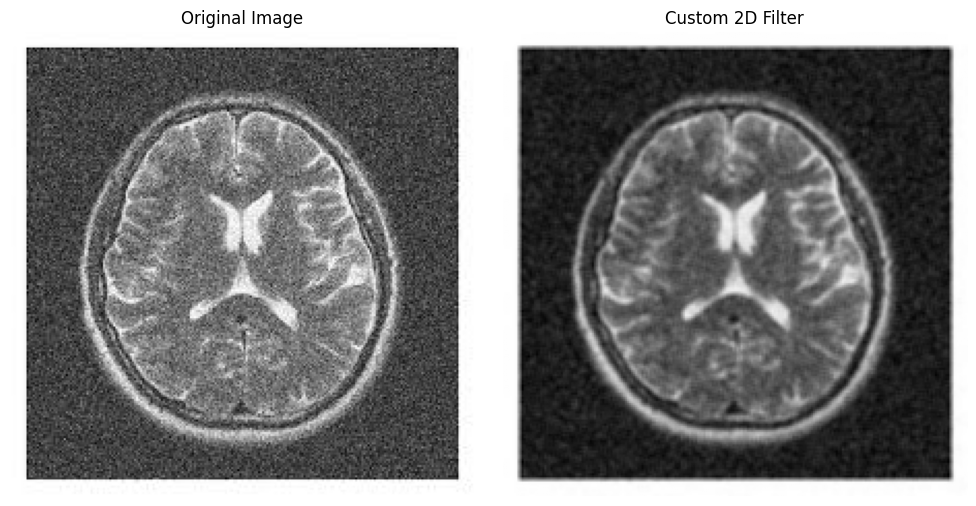

In [26]:
# By OpenCV
cv2.imshow("Original Image", img)
cv2.imshow("Custom 2D Filter", filtered_2d)
cv2.waitKey(0)
cv2.destroyAllWindows()

# By Matplotlib
plt.figure(figsize = (10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap = "gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(filtered_2d, cmap = "gray")
plt.axis("off")
plt.title("Custom 2D Filter")

plt.tight_layout()
plt.show()

✔ Reduces noise   
✖ Slightly blurs edges

---

### Built-in Averaging Blur

OpenCV provides a simpler way to do the same thing:

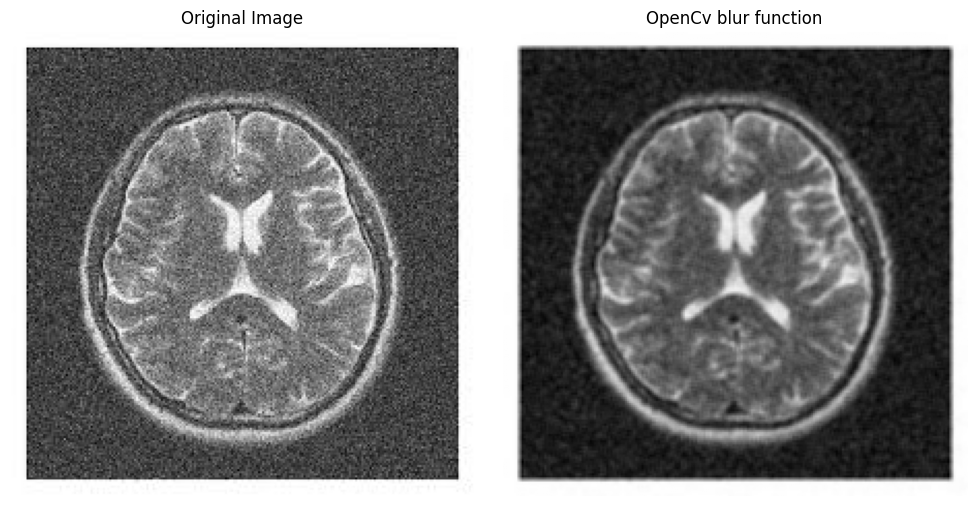

In [27]:
blur = cv2.blur(img, (3, 3))

plt.figure(figsize = (10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap = "gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(blur, cmap = "gray")
plt.axis("off")
plt.title("OpenCv blur function")

plt.tight_layout()
plt.show()

This internally does the same operation as our custom averaging filter.

---

### Gaussian Blur (Better Edge Preservation)

Instead of equal weights, **Gaussian blur** uses a bell-shaped curve.

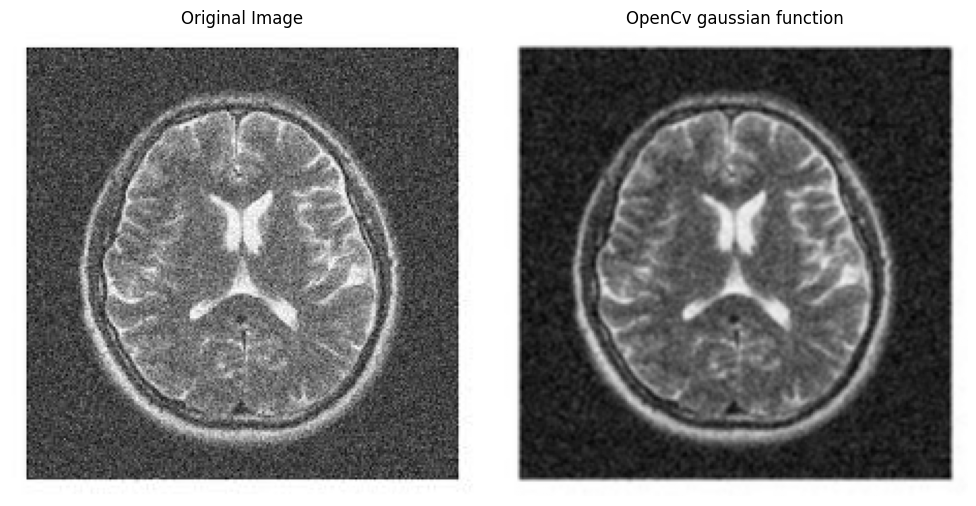

In [29]:
gaussian = cv2.GaussianBlur(img, (3, 3), 0)

plt.figure(figsize = (10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap = "gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(gaussian, cmap = "gray")
plt.axis("off")
plt.title("OpenCv gaussian function")

plt.tight_layout()
plt.show()

Advantages:
- Central pixels get higher weight
- Smoother results than simple averaging
- Commonly used in microscopy preprocessing

---

### Median Blur (Non-linear Filter)

Median filtering replaces each pixel with the **median of its neighbors**.

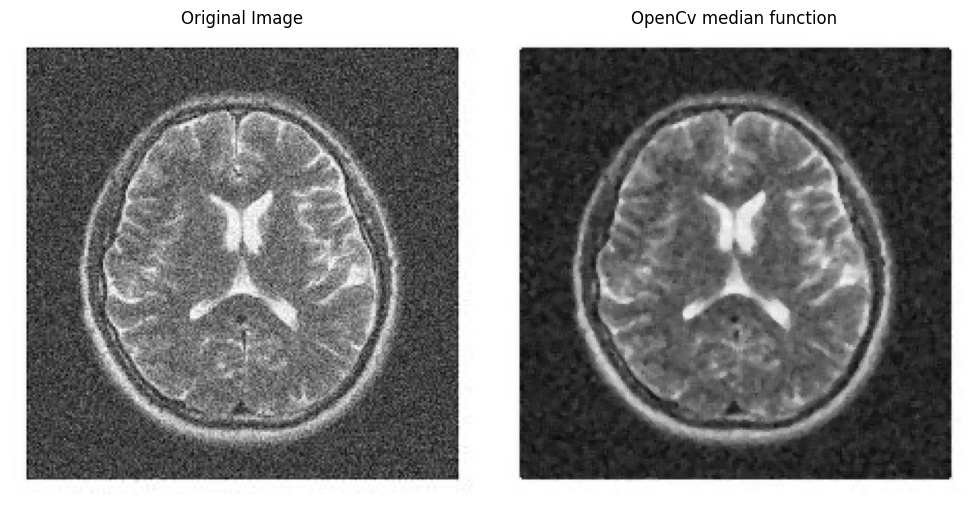

In [30]:
median = cv2.medianBlur(img, 3)

plt.figure(figsize = (10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap = "gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(median, cmap = "gray")
plt.axis("off")
plt.title("OpenCv median function")

plt.tight_layout()
plt.show()

Why use median blur?

- Excellent for salt-and-pepper noise
- Preserves edges better than Gaussian blur
- Very popular in biological image processing

---

### Bilateral Filter (Edge-Preserving Denoising)

One of the **best filters for microscopy images**.

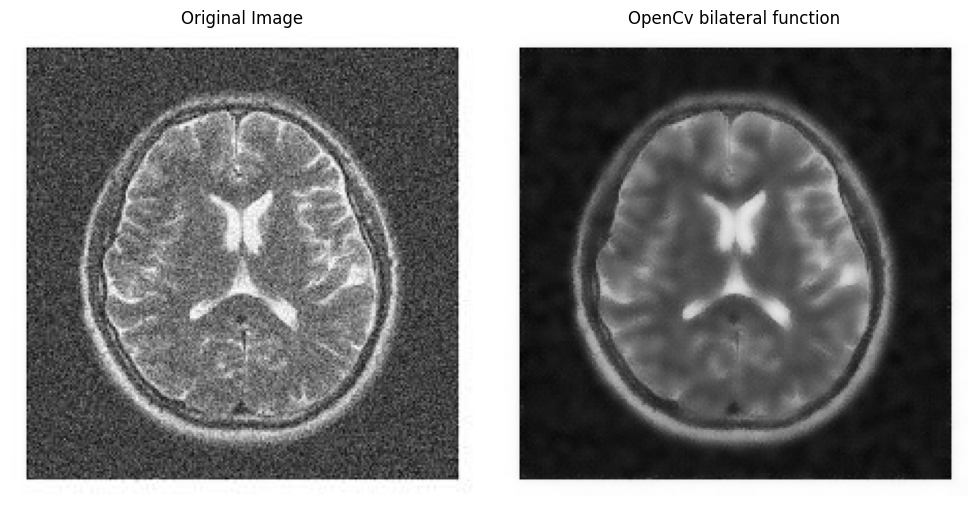

In [31]:
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

plt.figure(figsize = (10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap = "gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(bilateral, cmap = "gray")
plt.axis("off")
plt.title("OpenCv bilateral function")

plt.tight_layout()
plt.show()

What makes it special?
- Considers both spatial distance and intensity difference
- Strong noise reduction
- Preserves edges extremely well

⚠ Slower than other filters, but worth it for high-quality results

---

| Filter Type | Noise Reduction | Edge Preservation |
| ----------- | --------------- | ----------------- |
| Averaging   | Low             | Poor              |
| Gaussian    | Medium          | Medium            |
| Median      | Medium          | Good              |
| Bilateral   | High            | Excellent         |

---

### Edge Detection with Canny
Edge detection highlights areas of **strong intensity change**.   
We’ll use **Canny Edge Detection**, one of the most popular algorithms.

#### Load a Microscopy Image

In [3]:
img = cv2.imread("pbs.jpg", 0)
cv2.imshow("Original Image", img)

cv2.waitKey(0)
cv2.destroyAllWindows()

#### Applying Canny Edge Detection

In [4]:
edges = cv2.Canny(img, 100, 200)

- `100` → Lower threshold
- `200` → Upper threshold

These values control **edge sensitivity** and should be tuned for each image.

#### Display the Edges

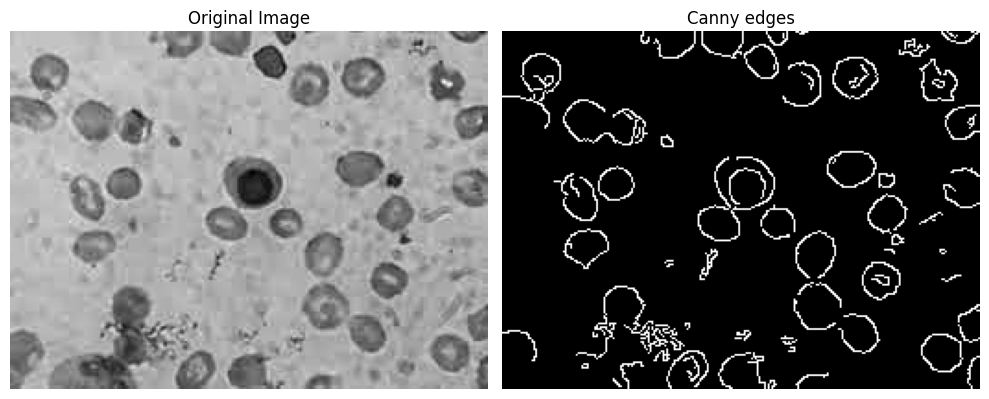

In [6]:
plt.figure(figsize = (10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap = "gray")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap = "gray")
plt.axis("off")
plt.title("Canny edges")

plt.tight_layout()
plt.show()

✔ Highlights cells structures   
✔ Captures sharp transitions   
✔ Useful for segmentation and morphology analysis   

---

**When to Use Edge Detection?**
- Identifying **cell boundaries**
- Tracing neurons, fibers, or membranes
- Preparing images for **thresholding** or **segmentation**